# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix,classification_report

import shap

import joblib

import warnings
warnings.filterwarnings('ignore')

# Data Loading and Bacis information

In [2]:
df = pd.read_csv('dataset.csv')

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.shape

(32581, 12)

In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


# EDA

In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df.loan_status.value_counts()

# 0 -> Non Defaulter
# 1 -> Defaulter

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(165)

<Axes: xlabel='loan_amnt', ylabel='Count'>

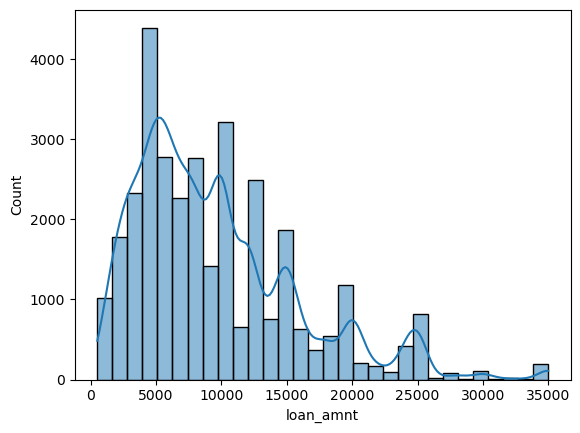

In [10]:
sns.histplot(df['loan_amnt'],bins = 30,kde=True)

<Axes: xlabel='person_income', ylabel='Count'>

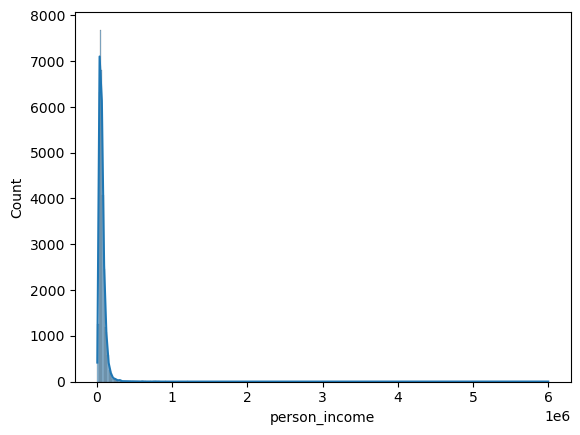

In [11]:
sns.histplot(df['person_income'],kde=True)

<Axes: xlabel='loan_intent', ylabel='count'>

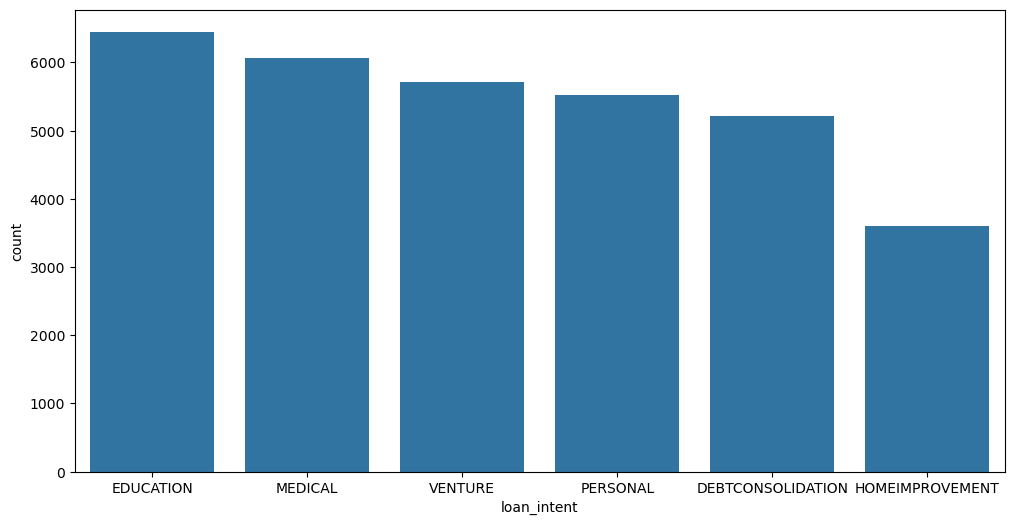

In [12]:
plt.figure(figsize = (12,6))
sns.countplot(x=df['loan_intent'],order=df['loan_intent'].value_counts().index)

<Axes: xlabel='person_age', ylabel='Count'>

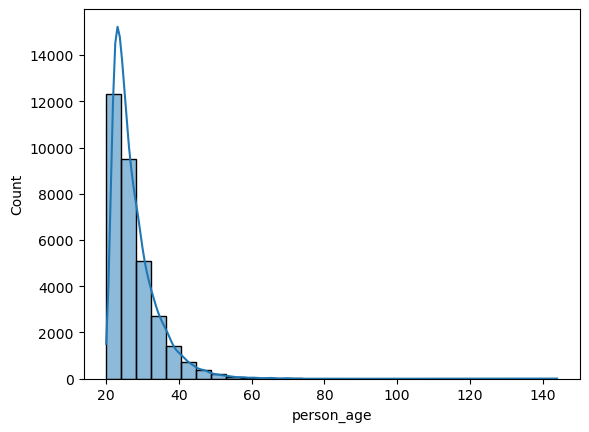

In [13]:
sns.histplot(df['person_age'],bins=30, kde=True)

<Axes: xlabel='loan_status', ylabel='person_age'>

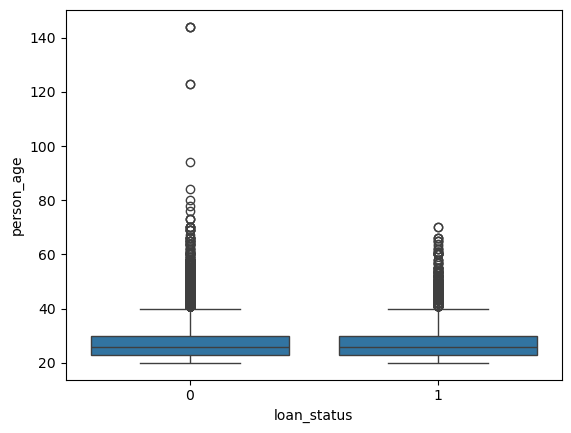

In [14]:
sns.boxplot(x=df['loan_status'], y=df['person_age'])

<Axes: xlabel='person_age', ylabel='Count'>

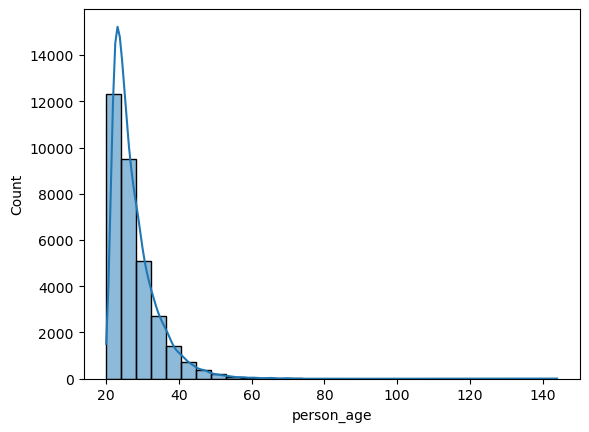

In [15]:
sns.histplot(df["person_age"],bins=30,kde='True')

Text(0.5, 1.0, 'Default Rate by Age Group')

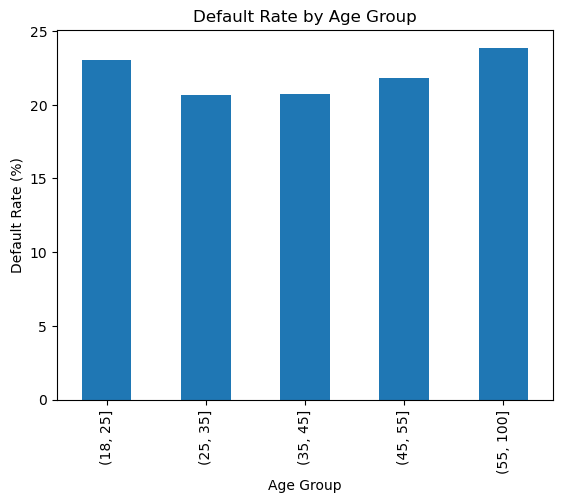

In [16]:
bins = [18, 25, 35, 45, 55, 100]
age_default = (
    df.groupby(pd.cut(df["person_age"], bins=bins))["loan_status"].mean() * 100
)

age_default.plot(kind="bar")

plt.ylabel("Default Rate (%)")
plt.xlabel("Age Group")
plt.title("Default Rate by Age Group")

<Axes: xlabel='person_home_ownership', ylabel='count'>

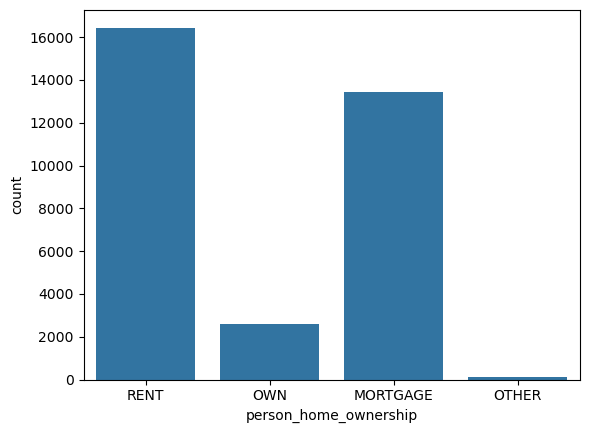

In [17]:
sns.countplot(x=df['person_home_ownership'])

<Axes: >

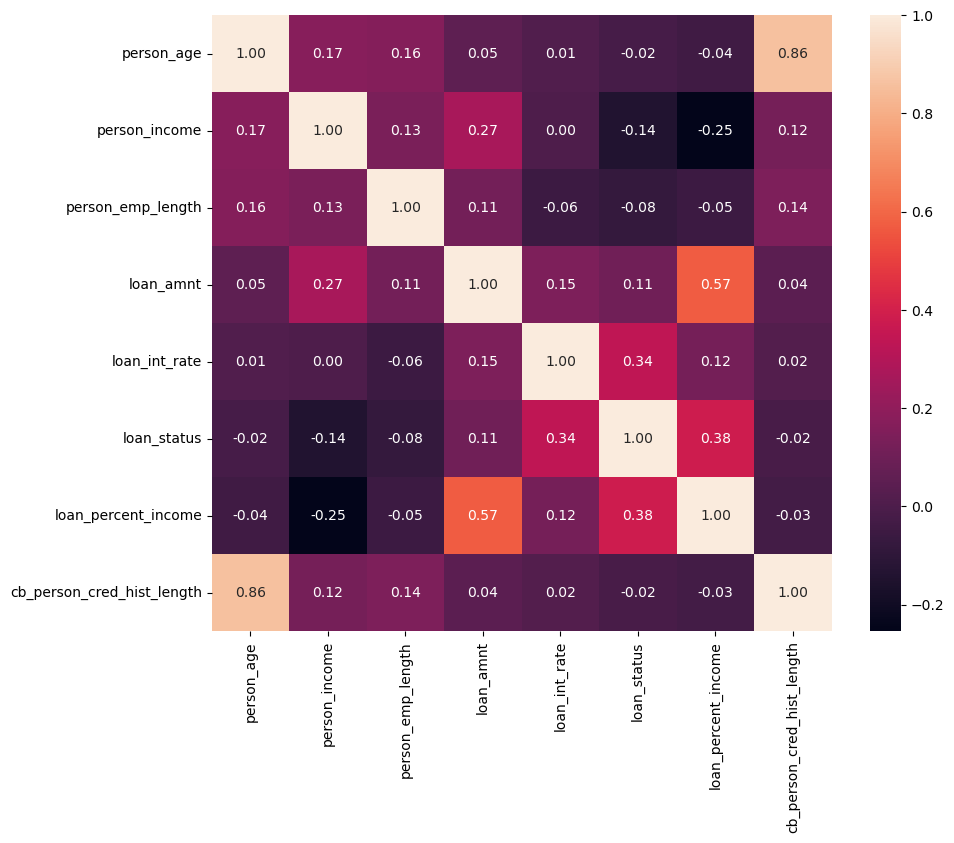

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, fmt=".2f")

In [19]:
df.select_dtypes(include="number").skew()

person_age                     2.581393
person_income                 32.865349
person_emp_length              2.614455
loan_amnt                      1.192477
loan_int_rate                  0.208550
loan_status                    1.364888
loan_percent_income            1.064669
cb_person_cred_hist_length     1.661790
dtype: float64

In [20]:
num_cols = df.select_dtypes(include='number').drop(columns='loan_status')
Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
outliers = (num_cols < lower_bound) | (num_cols > upper_bound)
print(outliers.sum())

person_age                    1494
person_income                 1484
person_emp_length              853
loan_amnt                     1689
loan_int_rate                    6
loan_percent_income            651
cb_person_cred_hist_length    1142
dtype: int64


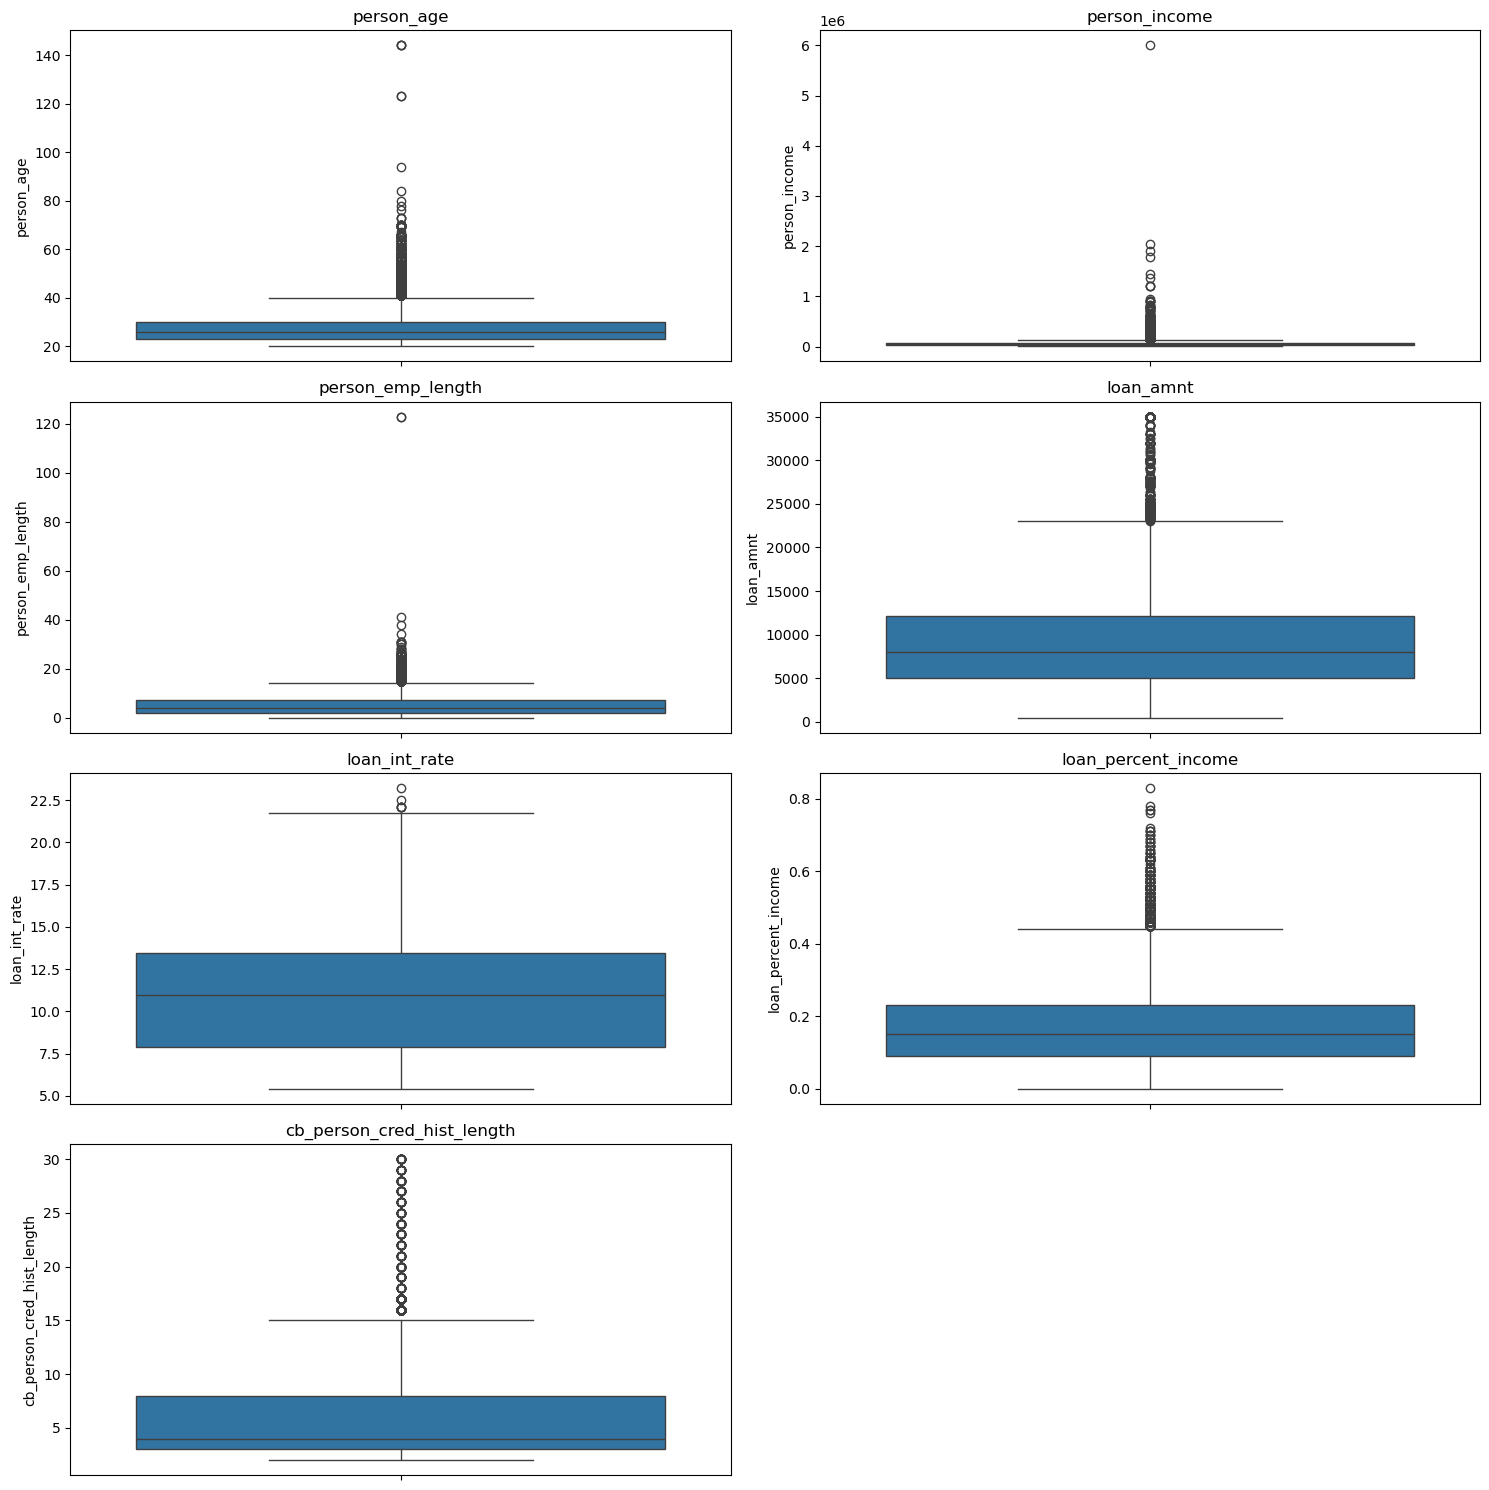

In [21]:
plt.figure(figsize=(15,15))
for i, col in enumerate(num_cols):
    plt.subplot(4,2,i+1)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()

In [22]:
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

df[df['person_emp_length'] > df['person_age']]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


In [23]:
df["person_income"].describe(percentiles=[0.90, 0.95, 0.99, 0.995]).round(2)

count      31679.00
mean       66490.10
std        52768.79
min         4000.00
50%        56000.00
90%       112000.00
95%       139992.80
99%       227610.00
99.5%     300000.00
max      2039784.00
Name: person_income, dtype: float64

In [24]:
train_df = df.copy()

In [25]:
x = train_df.drop('loan_status',axis = 1)
y = train_df['loan_status']

x_train,x_test,y_train,y_test = train_test_split(x,y, stratify=y, test_size = 0.2, random_state=42)

In [26]:
income_cap = x_train["person_income"].quantile(0.99)

x_train["person_income"] = x_train["person_income"].clip(upper=income_cap)
x_test["person_income"] = x_test["person_income"].clip(upper=income_cap)

In [27]:
num_cols = x_train.select_dtypes(include='number').columns.tolist()
num_cols

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length']

In [28]:
cat_cols = x_train.select_dtypes(include='object').columns.tolist()
cat_cols

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [29]:
num_pipeline = Pipeline(steps=[
    ('impute',SimpleImputer(strategy = 'median')),
    ('skewness',PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler())                            
])

cat_pipeline = Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
    
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric',num_pipeline,num_cols),
    ('categorical',cat_pipeline,cat_cols)
])

In [30]:
preprocessor

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [31]:
models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced',random_state=42),
    'Random Forest' : RandomForestClassifier(class_weight='balanced',random_state=42),
    'XGBoost' : XGBClassifier(random_state=42, eval_metric='logloss')
}

In [32]:
results = []
for name, model in models.items():
    pip = Pipeline(steps=[('preprocessor',preprocessor),('classifier',model)])
    pip.fit(x_train,y_train)
    y_pred= pip.predict(x_test)
    y_prob = pip.predict_proba(x_test)[:,1]

    results.append({
    'Model' : name,
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precission' : precision_score(y_test,y_pred),
    'Recall' : recall_score(y_test,y_pred),
    'F1 Score' : f1_score(y_test,y_pred),
    'ROC-AUC' : roc_auc_score(y_test,y_prob)
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precission,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.797664,0.519904,0.794139,0.628406,0.874508
1,Random Forest,0.937184,0.972630,0.728938,0.833333,0.935002
2,XGBoost,0.936869,0.953052,0.743590,0.835391,0.950312


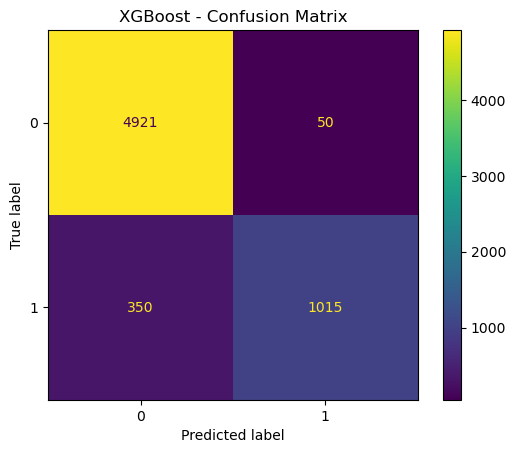

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("XGBoost - Confusion Matrix")
plt.show()

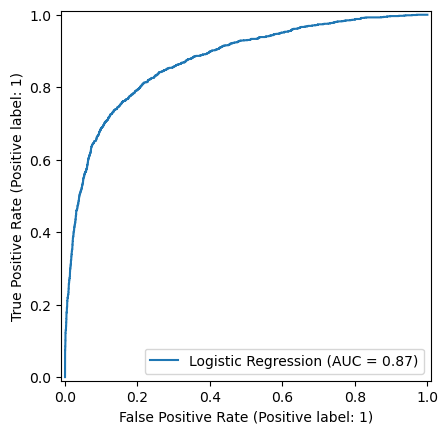

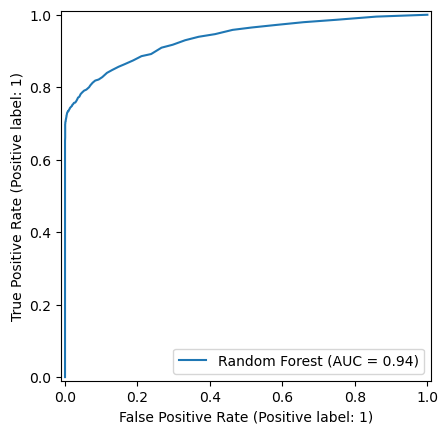

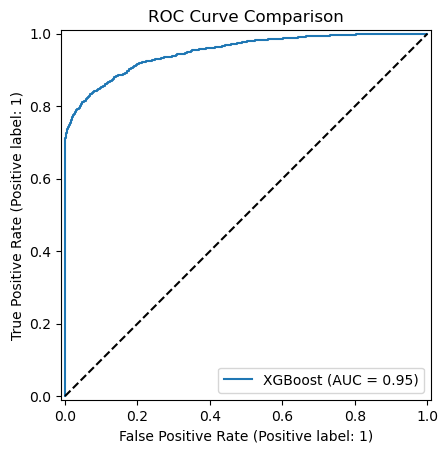

In [34]:
from sklearn.metrics import RocCurveDisplay

for name, model in models.items():

    pip = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pip.fit(x_train, y_train)

    RocCurveDisplay.from_estimator(
        pip,
        x_test,
        y_test,
        name=name
    )

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.show()

In [35]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', models['XGBoost'])
])

xgb_pipeline.fit(x_train, y_train)

y_prob = xgb_pipeline.predict_proba(x_test)[:, 1]
y_prob

array([7.4770381e-03, 4.9746071e-05, 7.7822653e-04, ..., 1.5979998e-02,
       1.5977986e-01, 2.5585028e-03], shape=(6336,), dtype=float32)

In [36]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred_threshold),
        'Recall': recall_score(y_test, y_pred_threshold),
        'F1 Score': f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.2,0.761204,0.833700,0.795804
1,0.3,0.854101,0.793407,0.822636
2,0.4,0.914410,0.767033,0.834263
3,0.5,0.953052,0.743590,0.835391
4,0.6,0.972630,0.728938,0.833333
5,0.7,0.991870,0.715018,0.830992


Among the tested thresholds (0.2–0.7), 0.5 achieved the highest F1-score (0.842), while maintaining high precision (0.962) and a recall of 0.748. Therefore, 0.5 was selected as the operating threshold.

In [37]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [3, 4, 5, 6, 8],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'classifier__min_child_weight': [1, 3, 5],
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__min_child_weight': [1, 3, ...], ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [38]:
print(random_search.best_params_)
print(random_search.best_score_)

{'classifier__subsample': 1.0, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 3, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}
0.9500465715591935


In [39]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(x_test)
y_prob = best_xgb.predict_proba(x_test)[:, 1]

In [40]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9376578282828283
Precision: 0.9566854990583804
Recall   : 0.7443223443223443
F1 Score : 0.8372476308199424
ROC-AUC  : 0.9534831694155772


In [41]:
fitted_preprocessor = best_xgb.named_steps["preprocessor"]

xgb_model = best_xgb.named_steps["classifier"]

X_test_transformed = fitted_preprocessor.transform(x_test)
feature_names = fitted_preprocessor.get_feature_names_out()

importances = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(20)

,Feature,Importance
9,categorical__person_home_ownership_OWN,0.090196
20,categorical__loan_grade_D,0.085132
10,categorical__person_home_ownership_RENT,0.081945
19,categorical__loan_grade_C,0.072559
5,numeric__loan_percent_income,0.071918
25,categorical__cb_person_default_on_file_Y,0.068818
11,categorical__loan_intent_DEBTCONSOLIDATION,0.065193
7,categorical__person_home_ownership_MORTGAGE,0.063143
17,categorical__loan_grade_A,0.050305
21,categorical__loan_grade_E,0.043560


In [42]:
importance_df = feature_importance_df.copy()

importance_df["Original_Feature"] = (
    importance_df["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

for col in cat_cols:
    mask = importance_df["Original_Feature"].str.startswith(col + "_")
    importance_df.loc[mask, "Original_Feature"] = col

grouped_importance = (
    importance_df
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

grouped_importance

,Original_Feature,Importance
3,loan_grade,0.347851
9,person_home_ownership,0.239230
5,loan_intent,0.179332
1,cb_person_default_on_file,0.074222
6,loan_percent_income,0.071918
4,loan_int_rate,0.029097
10,person_income,0.021633
8,person_emp_length,0.013426
7,person_age,0.009333
2,loan_amnt,0.008860


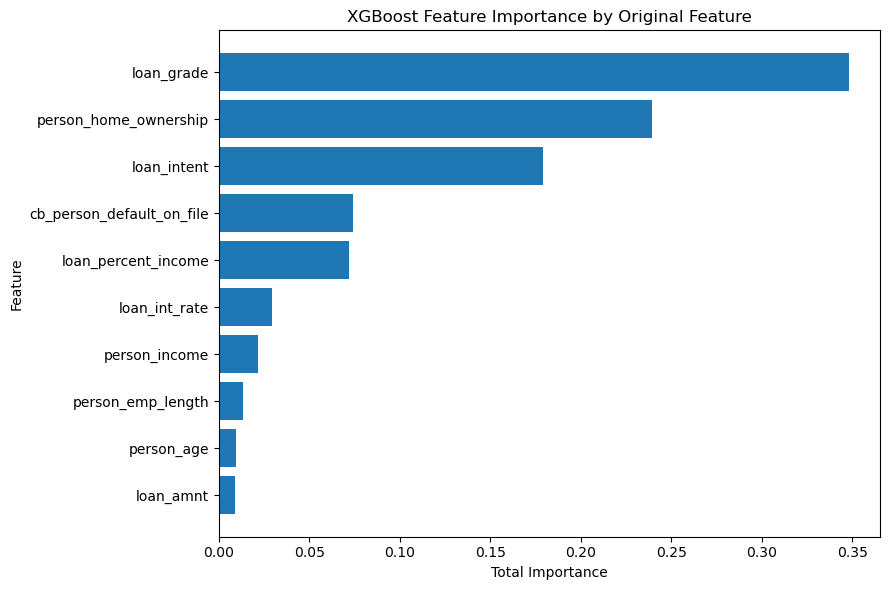

In [43]:
top_features = (
    grouped_importance
    .head(10)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Original_Feature"],
    top_features["Importance"]
)

plt.xlabel("Total Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance by Original Feature")

plt.tight_layout()
plt.show()

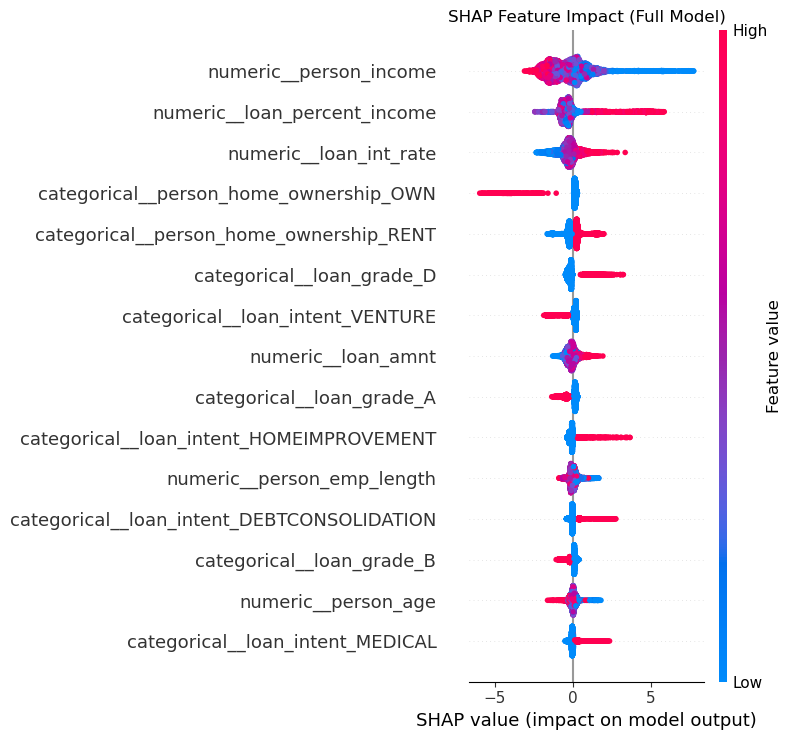

In [44]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_transformed)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values.values,
    X_test_transformed,
    feature_names=feature_names,
    show=False,
    max_display=15
)
plt.title("SHAP Feature Impact (Full Model)")
plt.tight_layout()
plt.show()

In [46]:
joblib.dump(best_xgb,"Credit_risk_prediction.joblib")

['Credit_risk_prediction.joblib']